In [1]:
import tensorflow as tf

# List all physical GPU devices
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is available!")
    for gpu in gpus:
        print(f"GPU Name: {gpu.name}, Type: {gpu.device_type}")
else:
    print("No GPU detected!")

2025-12-13 13:45:33.152015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765633533.544396      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765633533.668324      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

GPU is available!
GPU Name: /physical_device:GPU:0, Type: GPU
GPU Name: /physical_device:GPU:1, Type: GPU


In [2]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Dataset path
DATA_DIR = '/kaggle/input/cats-and-dogs-mini-dataset/'

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42
INITIAL_EPOCHS = 6


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.08,
    zoom_range=0.12,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)


Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Class indices: {'cats_set': 0, 'dogs_set': 1}


In [4]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model initially
for layer in base_model.layers:
    layer.trainable = False


I0000 00:00:1765633607.824206      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765633607.824760      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)


In [7]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ModelCheckpoint('/kaggle/working/resnet50_cats_dogs_best.h5', monitor='val_accuracy', save_best_only=True)
]


In [8]:
steps_per_epoch = max(1, train_generator.samples // BATCH_SIZE)
validation_steps = max(1, val_generator.samples // BATCH_SIZE)

history_head = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=INITIAL_EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6


I0000 00:00:1765633696.578331     130 service.cc:148] XLA service 0x7a252c0047a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765633696.579771     130 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765633696.579791     130 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765633698.114574     130 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/25 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5859 - loss: 0.6894 

I0000 00:00:1765633703.087237     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.5378 - loss: 0.6948

25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 890ms/step - accuracy: 0.5371 - loss: 0.6947 - val_accuracy: 0.4792 - val_loss: 0.6919
Epoch 2/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 469ms/step - accuracy: 0.5040 - loss: 0.6905 - val_accuracy: 0.4792 - val_loss: 0.6878
Epoch 3/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.5337 - loss: 0.6867

25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 504ms/step - accuracy: 0.5340 - loss: 0.6866 - val_accuracy: 0.5365 - val_loss: 0.6807
Epoch 4/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.5060 - loss: 0.6965

25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 502ms/step - accuracy: 0.5076 - loss: 0.6961 - val_accuracy: 0.6406 - val_loss: 0.6694
Epoch 5/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.5400 - loss: 0.6868

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 489ms/step - accuracy: 0.5406 - loss: 0.6867 - val_accuracy: 0.6771 - val_loss: 0.6666
Epoch 6/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 470ms/step - accuracy: 0.5674 - loss: 0.6796 - val_accuracy: 0.5781 - val_loss: 0.6724


In [9]:
# Unfreeze last 10 layers of ResNet50
for layer in base_model.layers[-10:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_finetune = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=5,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)


Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 628ms/step - accuracy: 0.5128 - loss: 0.7846 - val_accuracy: 0.5573 - val_loss: 0.6747
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 475ms/step - accuracy: 0.5496 - loss: 0.6912 - val_accuracy: 0.6510 - val_loss: 0.6628
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 463ms/step - accuracy: 0.6032 - loss: 0.6725 - val_accuracy: 0.6250 - val_loss: 0.6685
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 470ms/step - accuracy: 0.6011 - loss: 0.6601 - val_accuracy: 0.6042 - val_loss: 0.6679
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 468ms/step - accuracy: 0.6372 - loss: 0.6416 - val_accuracy: 0.6510 - val_loss: 0.6684


In [10]:
# Evaluate model on validation set
val_loss, val_accuracy = model.evaluate(val_generator, steps=validation_steps)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - accuracy: 0.8100 - loss: 0.6352
Validation Loss: 0.6622
Validation Accuracy: 0.6719


In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict labels for validation set
val_generator.reset()
y_pred = model.predict(val_generator, steps=validation_steps, verbose=1)
y_pred_labels = (y_pred > 0.5).astype(int)

# True labels
y_true = val_generator.classes[:len(y_pred_labels)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
print("Confusion Matrix:")
print(cm)

# Classification report
cr = classification_report(y_true, y_pred_labels, target_names=list(val_generator.class_indices.keys()))
print("Classification Report:")
print(cr)


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 321ms/step
Confusion Matrix:
[[90 10]
 [63 29]]
Classification Report:
              precision    recall  f1-score   support

    cats_set       0.59      0.90      0.71       100
    dogs_set       0.74      0.32      0.44        92

    accuracy                           0.62       192
   macro avg       0.67      0.61      0.58       192
weighted avg       0.66      0.62      0.58       192



In [12]:
import os
import random
from tensorflow.keras.preprocessing import image

# Pick 2 random images from each class
test_images = []
test_labels = []

for label, folder in enumerate(['cats_set', 'dogs_set']):
    folder_path = os.path.join(DATA_DIR, folder)
    files = os.listdir(folder_path)
    test_images.extend([os.path.join(folder_path, f) for f in random.sample(files, 2)])
    test_labels.extend([label]*2)

# Predict and display results
for img_path, true_label in zip(test_images, test_labels):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = np.expand_dims(image.img_to_array(img)/255.0, axis=0)
    pred = model.predict(img_array)
    pred_label = 1 if pred[0][0] > 0.5 else 0
    print(f"Image: {os.path.basename(img_path)}, True: {['Cat','Dog'][true_label]}, Predicted: {['Cat','Dog'][pred_label]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Image: cat.4284.jpg, True: Cat, Predicted: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Image: cat.4489.jpg, True: Cat, Predicted: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Image: dog.4080.jpg, True: Dog, Predicted: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Image: dog.4412.jpg, True: Dog, Predicted: Cat


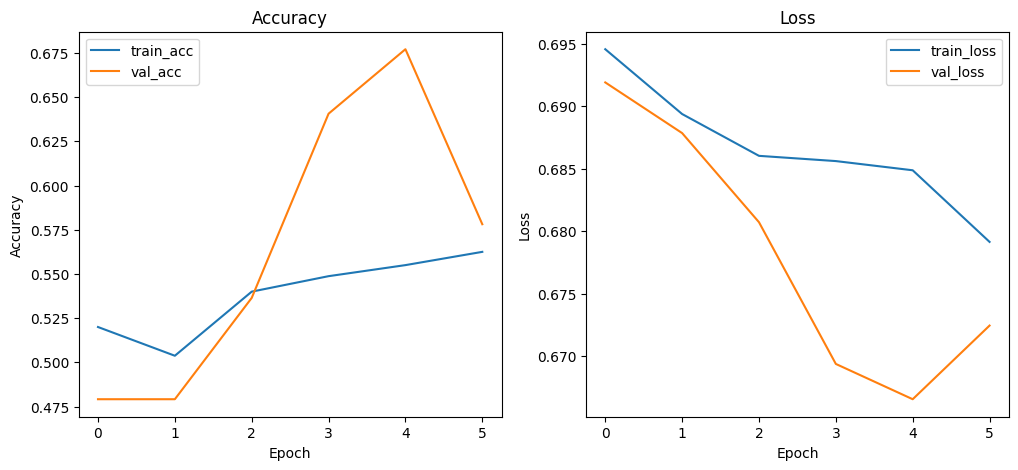

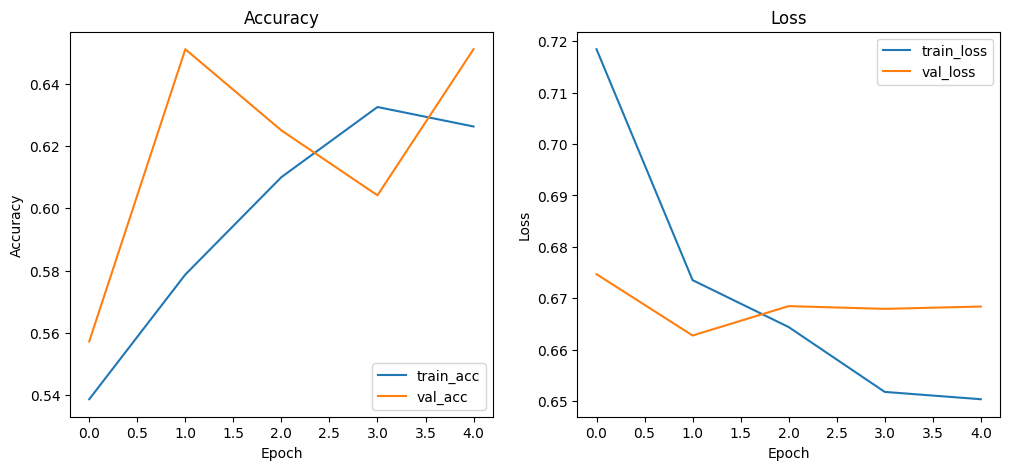

In [13]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history_head)      # classifier head training
plot_history(history_finetune)  # fine-tuning
